## Import

In [58]:
import pyrealsense2 as rs
import numpy as np
import matplotlib.pyplot as plt
print("Imports ready")

Imports ready


## Capture Data (Numpy Points)

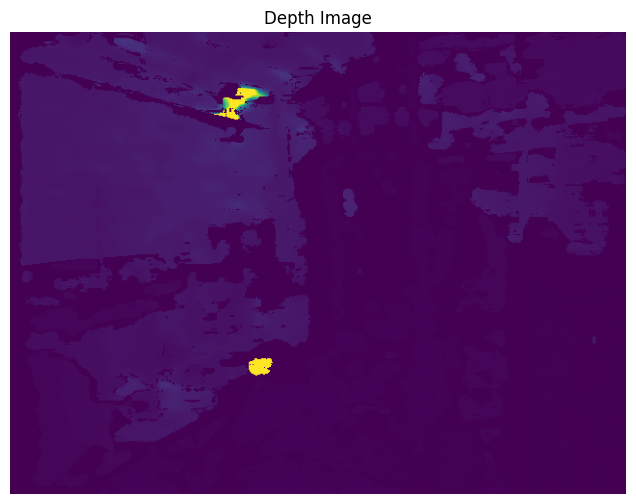

Captured depth image: (480, 640), dtype=uint16


In [59]:
pipeline = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
profile = pipeline.start(config)

# ดึงค่า Intrinsic ของกล้องเพื่อใช้คำนวณ Point Cloud เอง
intr = profile.get_stream(rs.stream.depth).as_video_stream_profile().get_intrinsics()

for _ in range(30): pipeline.wait_for_frames() # Warm up
frames = pipeline.wait_for_frames()
depth_frame = frames.get_depth_frame()
depth_image = np.asanyarray(depth_frame.get_data())
pipeline.stop()
plt.figure(figsize=(8, 6))
plt.imshow(depth_image)
plt.title("Depth Image")
plt.axis("off")
plt.show()
print(f"Captured depth image: {depth_image.shape}, dtype={depth_image.dtype}")

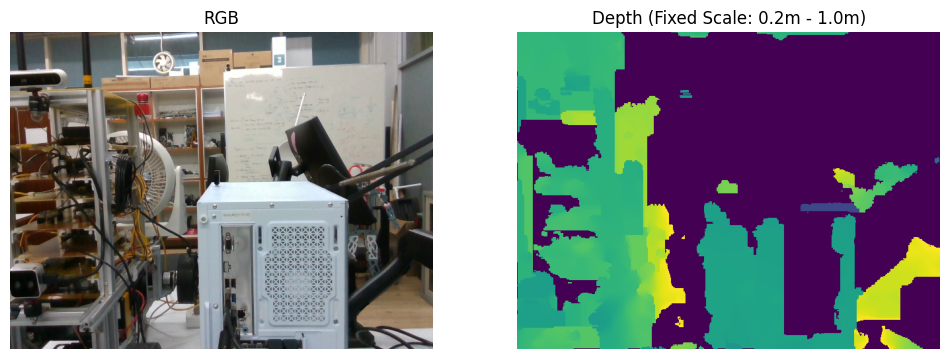

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import pyrealsense2 as rs

# 1. ตั้งค่า Pipeline และ Config
pipeline = rs.pipeline()
config = rs.config()
config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
pipeline.start(config)
align = rs.align(rs.stream.color)

# ---------------------------------------------------------
# 🌟 2. ประกาศใช้งาน Post-Processing Filters
# ---------------------------------------------------------
spatial = rs.spatial_filter()    
temporal = rs.temporal_filter()  
hole_filling = rs.hole_filling_filter()

# ---------------------------------------------------------
# 🌟 3. ตั้งค่าระยะตายตัว (Fixed Parameters)
# ---------------------------------------------------------
MAX_DEPTH_MM = 1000  # ล็อกระยะไกลสุดที่ 3 เมตร (3000 มิลลิเมตร)
MIN_DEPTH_MM = 100   # ตัดระยะใกล้สุดที่เซนเซอร์บอดออก (200 มิลลิเมตร)

try:
    for _ in range(300):
        frames = pipeline.wait_for_frames()
        aligned = align.process(frames)
        depth_frame = aligned.get_depth_frame()
        color_frame = aligned.get_color_frame()
        if not depth_frame or not color_frame:
            continue

        # นำข้อมูล Depth ผ่านฟิลเตอร์
        depth_frame = spatial.process(depth_frame)
        depth_frame = temporal.process(depth_frame)
        depth_frame = hole_filling.process(depth_frame)

        depth_image = np.asanyarray(depth_frame.get_data())
        color_image = np.asanyarray(color_frame.get_data())
        color_image = cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB)

        # ---------------------------------------------------------
        # 🌟 4. ตัดข้อมูลนอกระยะการทำงานทิ้ง (Clipping)
        # ---------------------------------------------------------
        # จุดไหนที่ไกลกว่า 3 เมตร หรือใกล้กว่า 20 ซม. ให้ตั้งค่าเป็น 0 (ตัดทิ้ง/หลุมดำ)
        depth_image = np.where((depth_image > MAX_DEPTH_MM) | (depth_image < MIN_DEPTH_MM), 0, depth_image)

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        
        axes[0].imshow(color_image)
        axes[0].set_title('RGB')
        axes[0].axis('off')
        
        # 🌟 5. แสดงผลโดยล็อกสเกล vmax ไว้ที่ MAX_DEPTH_MM เสมอ
        axes[1].imshow(depth_image, cmap='viridis', vmin=0, vmax=MAX_DEPTH_MM)
        axes[1].set_title(f'Depth (Fixed Scale: 0.2m - {MAX_DEPTH_MM/1000}m)')
        axes[1].axis('off')
        
        plt.show()

        time.sleep(0.03)
except KeyboardInterrupt:
    pass
finally:
    pipeline.stop()


## Voxel Filter Logic (The Core)

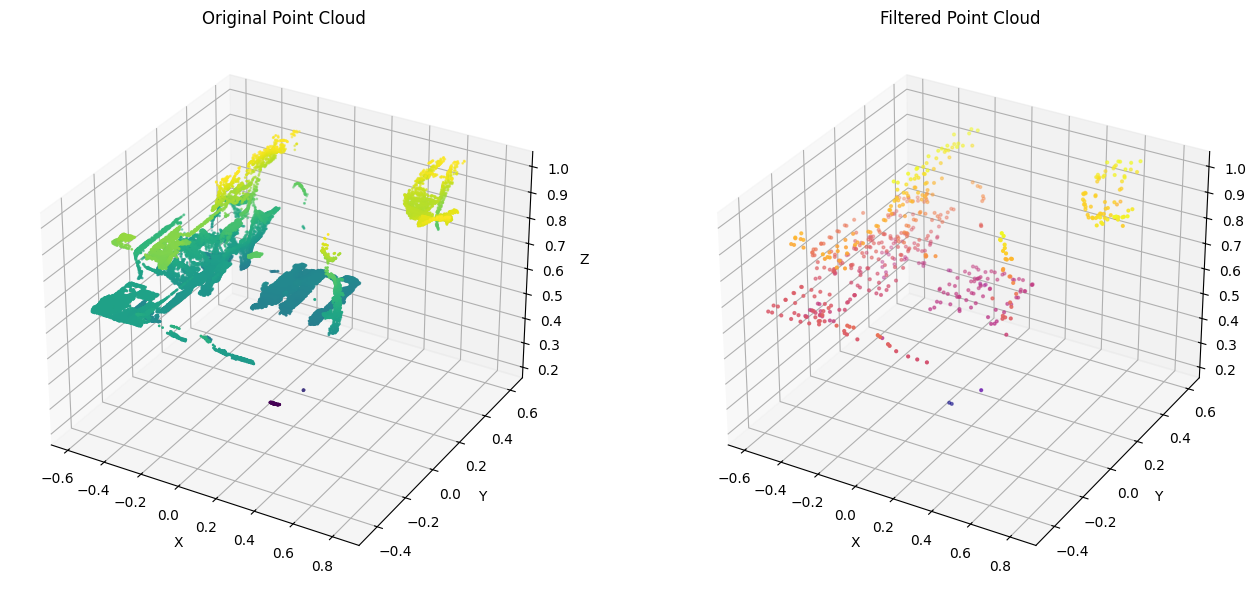

Original: 130366 points | Filtered: 563 points


In [61]:
# สร้าง Meshgrid ของพิกัดพิกเซล
v, u = np.mgrid[0:480, 0:640]
z = depth_image * 0.001 # แปลงเป็นเมตร
mask = (z > 0) & (z < 3.0) # กรองระยะ 0-3 เมตร

# คำนวณ X, Y, Z (Point Cloud) ด้วย Numpy
x = (u - intr.ppx) * z / intr.fx
y = (v - intr.ppy) * z / intr.fy
pts = np.stack((x[mask], y[mask], z[mask]), axis=-1)

# Voxel Filter: หารด้วยขนาด Voxel แล้วปัดเศษ จากนั้นหาค่า Unique
voxel_size = 0.05
voxel_coords = np.round(pts / voxel_size).astype(int)
_, indices = np.unique(voxel_coords, axis=0, return_index=True)
filtered_pts = pts[indices]

if len(pts) == 0:
    print("No valid depth points found")
else:
    sample_size = min(len(pts), 30000)
    sample_indices = np.random.choice(len(pts), sample_size, replace=False)
    sampled_pts = pts[sample_indices]

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.scatter(sampled_pts[:, 0], sampled_pts[:, 1], sampled_pts[:, 2], s=1, c=sampled_pts[:, 2], cmap="viridis")
    ax1.set_title("Original Point Cloud")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.scatter(filtered_pts[:, 0], filtered_pts[:, 1], filtered_pts[:, 2], s=4, c=filtered_pts[:, 2], cmap="plasma")
    ax2.set_title("Filtered Point Cloud")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    plt.tight_layout()
    plt.show()

print(f"Original: {len(pts)} points | Filtered: {len(filtered_pts)} points")